<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_pr_2_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print(df.head())

# Check missing values
print(df.isnull().sum())

# Separate Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

Saving diabetes.csv to diabetes.csv
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy without PCA/LDA:",
      accuracy_score(y_test, pred))

Accuracy without PCA/LDA: 0.7532467532467533


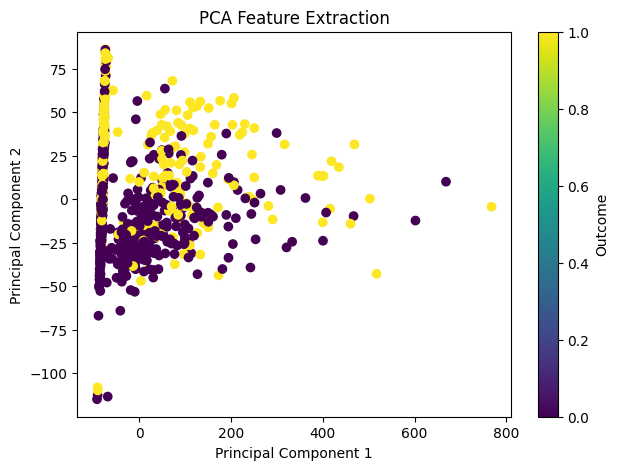

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=y,
            cmap='viridis')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Feature Extraction")

plt.colorbar(label="Outcome")

plt.show()

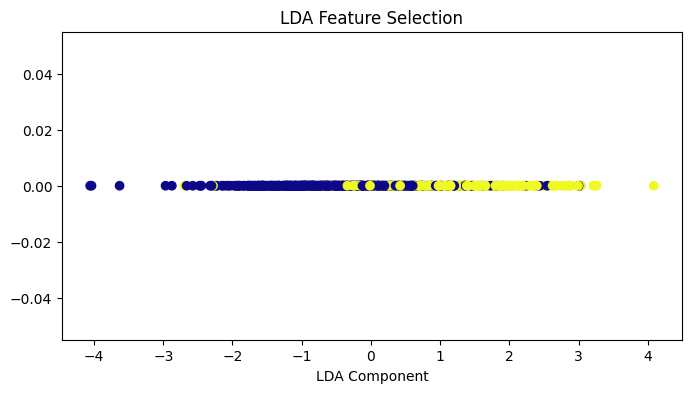

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X,y)

plt.figure(figsize=(8,4))

plt.scatter(X_lda,
            [0]*len(X_lda),
            c=y,
            cmap='plasma')

plt.title("LDA Feature Selection")
plt.xlabel("LDA Component")

plt.show()

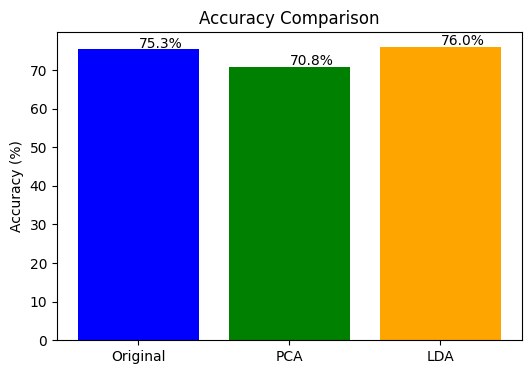

In [ ]:
accuracies = [
    acc_original*100,
    acc_pca*100,
    acc_lda*100
]

methods = [
    "Original",
    "PCA",
    "LDA"
]

plt.figure(figsize=(6,4))

plt.bar(methods,
        accuracies,
        color=['blue','green','orange'])

plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")

for i,v in enumerate(accuracies):
    plt.text(i,v+0.5,f"{v:.1f}%")

plt.show()

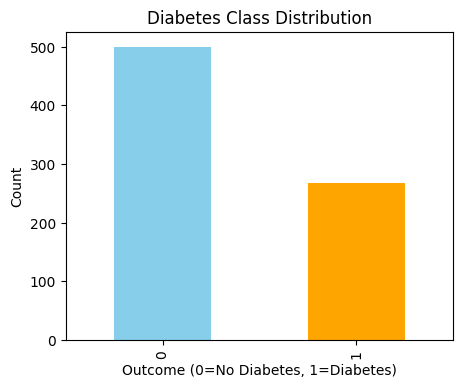

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue','orange'])

plt.title("Diabetes Class Distribution")
plt.xlabel("Outcome (0=No Diabetes, 1=Diabetes)")
plt.ylabel("Count")

plt.show()

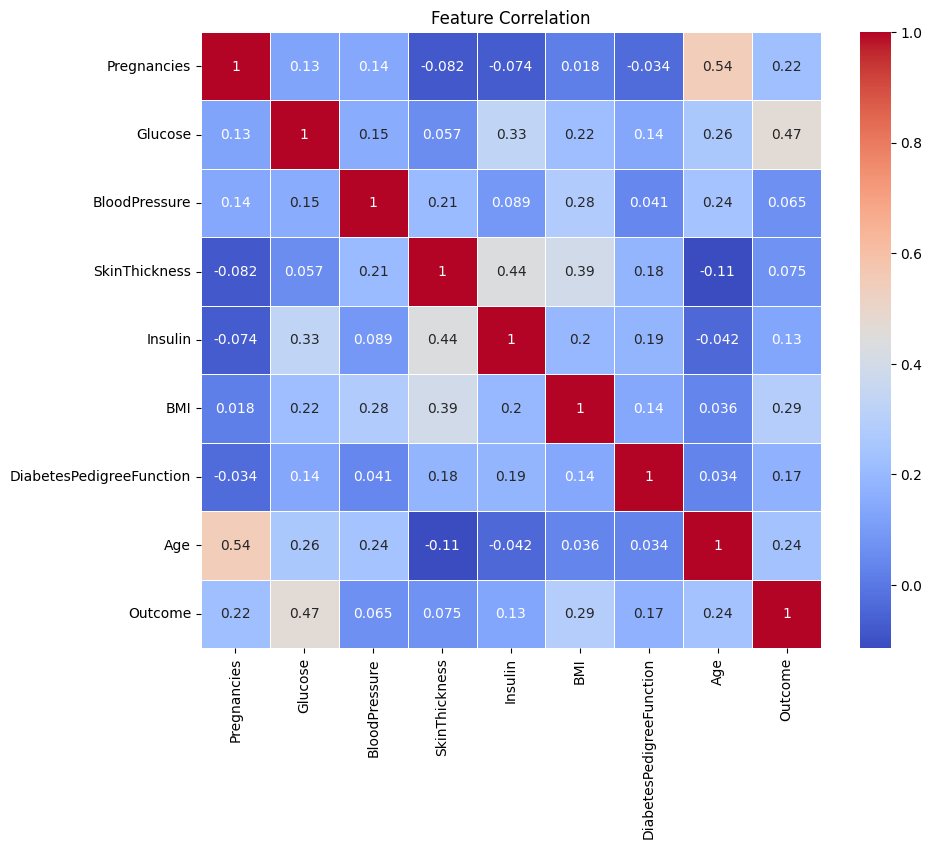

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation")

plt.show()